# **Imports**

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.layers import Reshape
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# **Load Images**

In [2]:
def load_images(folder_path, image_size=(64,64)):
    data = []
    labels = []

    label = os.path.basename(folder_path)  # Extract the label from the folder name

    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        if os.path.isfile(img_path):  # Check if it is a file
            img = cv2.imread(img_path)
            if img is not None:  # Check if the image was read correctly
                img = cv2.resize(img, image_size)  # Resize images to a common size
                data.append(img)
                labels.append(label)

    return np.array(data), np.array(labels)

dataset_path = r"/kaggle/input/datasets/anikdas1124/indian-uav-soyabean/INDIAN _UAV"

# Load images for each type of chest X-ray
data_Healthy_Soyabean, labels_Healthy_Soyabean = load_images(os.path.join(dataset_path, 'Healthy_Soyabean'))
data_rust, labels_rust = load_images(os.path.join(dataset_path, 'rust'))
data_Soyabean_Mosaic, labels_Soyabean_Mosaic = load_images(os.path.join(dataset_path, 'Soyabean_Mosaic'))
data_Soyabean_Semilooper_Pest_Attack, labels_Soyabean_Semilooper_Pest_Attack = load_images(os.path.join(dataset_path, 'Soyabean Semilooper_Pest_Attack'))

# **Concatenate**

In [3]:
All_data = np.concatenate([
    data_Healthy_Soyabean,
    data_rust,
    data_Soyabean_Mosaic,
    data_Soyabean_Semilooper_Pest_Attack
])

All_labels = np.concatenate([
    labels_Healthy_Soyabean,
    labels_rust,
    labels_Soyabean_Mosaic,
    labels_Soyabean_Semilooper_Pest_Attack
])

# **Normalization**

In [4]:
All_data_normalized = All_data / 255.0

# **Encode & Split**

In [5]:
label_encoder = LabelEncoder()
all_labels_encoded = label_encoder.fit_transform(All_labels)
train_data, test_data, train_labels, test_labels = train_test_split(
    All_data_normalized, all_labels_encoded, test_size=0.20, random_state=42
)

# **Plot Data Distribution**

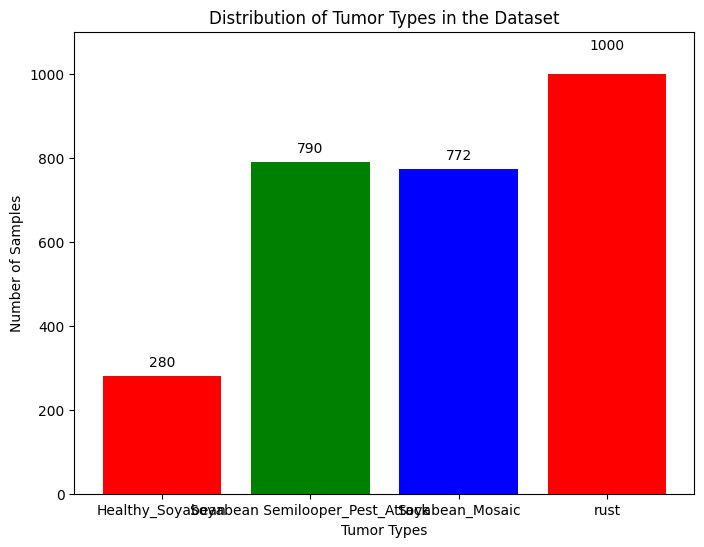

In [6]:
unique_labels, label_counts = np.unique(All_labels, return_counts=True)
plt.figure(figsize=(8, 6))

plt.bar(unique_labels, label_counts, color=['red', 'green', 'blue'])
plt.xlabel('Tumor Types')
plt.ylabel('Number of Samples')
plt.title('Distribution of Tumor Types in the Dataset')

max_count = max(label_counts)
plt.ylim(0, max_count + 0.1 * max_count)

for i, count in enumerate(label_counts):
    plt.text(i, count + 0.05 * max_count, str(count), ha='center', va='bottom' if count > 0.9 * max_count else 'top')

plt.show()

# FPN - RF - C4+C5 (Ablation Study)

In [7]:
def build_c4_c5_feature_extractor(input_shape=(64, 64, 3), fpn_channels=64):
    x_in = layers.Input(shape=input_shape)

    # Backbone (3 conv blocks, C4 and C5 both used)
    x = layers.Conv2D(18, 3, padding='same', activation='relu')(x_in)
    c3 = layers.MaxPooling2D(2)(x)   # 32x32x18

    x = layers.Conv2D(36, 3, padding='same', activation='relu')(c3)
    c4 = layers.MaxPooling2D(2)(x)   # 16x16x36

    x = layers.Conv2D(72, 3, padding='same', activation='relu')(c4)
    c5 = layers.MaxPooling2D(2)(x)   # 8x8x72

    # Lateral 1x1 on C4 and C5
    l4 = layers.Conv2D(fpn_channels, 1, padding='same')(c4)
    l5 = layers.Conv2D(fpn_channels, 1, padding='same')(c5)

    # Top-down fusion: upsample C5 lateral and add to C4 lateral
    l5_up = layers.UpSampling2D(2)(l5)
    p4 = layers.Add()([l4, l5_up])
    p4 = layers.Conv2D(fpn_channels, 3, padding='same', activation='relu')(p4)

    p5 = layers.Conv2D(fpn_channels, 3, padding='same', activation='relu')(l5)

    # GAP each level to a vector, then concatenate (C4+C5 fused features)
    p4_feat = layers.GlobalAveragePooling2D(name="c4_gap")(p4)
    p5_feat = layers.GlobalAveragePooling2D(name="c5_gap")(p5)
    feat_vec = layers.Concatenate(name="c4_c5_feat")([p4_feat, p5_feat])

    return models.Model(x_in, feat_vec, name="c4_c5_feature_extractor")

cnn_model_c4c5 = build_c4_c5_feature_extractor(input_shape=(64,64,3), fpn_channels=64)
cnn_model_c4c5.summary()

I0000 00:00:1784397387.837146      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "c4_c5_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        504 │ input_layer[0][0] │
│                     │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      5,868 │ max_pooling2d[0]… │
│                     │ 36)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 36)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     23,400 │ max_pooling2d_1[… │
│                     │ 72)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 72)  │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 8, 8, 64)  │      4,672 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │      2,368 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 16, 16,    │          0 │ conv2d_4[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 16,    │          0 │ conv2d_3[0][0],   │
│                     │ 64)               │            │ up_sampling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │     36,928 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 8, 8, 64)  │     36,928 │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ c4_gap              │ (None, 64)        │          0 │ conv2d_5[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ c5_gap              │ (None, 64)        │          0 │ conv2d_6[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ c4_c5_feat          │ (None, 128)       │          0 │ c4_gap[0][0],     │
│ (Concatenate)       │                   │            │ c5_gap[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 110,668 (432.30 KB)

 Trainable params: 110,668 (432.30 KB)

 Non-trainable params: 0 (0.00 B)

# C4+C5 - feature extraction

In [8]:
train_features_c4c5 = cnn_model_c4c5.predict(train_data, batch_size=64, verbose=0)
test_features_c4c5  = cnn_model_c4c5.predict(test_data,  batch_size=64, verbose=0)

def l2_normalize(a, axis=1, eps=1e-12):
    return a / np.maximum(np.linalg.norm(a, axis=axis, keepdims=True), eps)

train_features_c4c5 = l2_normalize(train_features_c4c5)
test_features_c4c5  = l2_normalize(test_features_c4c5)

train_features_c4c5_flattened = np.reshape(train_features_c4c5, (train_features_c4c5.shape[0], -1))
test_features_c4c5_flattened  = np.reshape(test_features_c4c5,  (test_features_c4c5.shape[0], -1))

I0000 00:00:1784397888.522728     129 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


# Random Forest, C4+C5

In [9]:
rf_model_c4c5 = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model_c4c5.fit(train_features_c4c5_flattened, train_labels)

rf_pred_labels_c4c5 = rf_model_c4c5.predict(test_features_c4c5_flattened)
rf_pred_probs_c4c5  = rf_model_c4c5.predict_proba(test_features_c4c5_flattened)

# confusion matrix - c4+c5

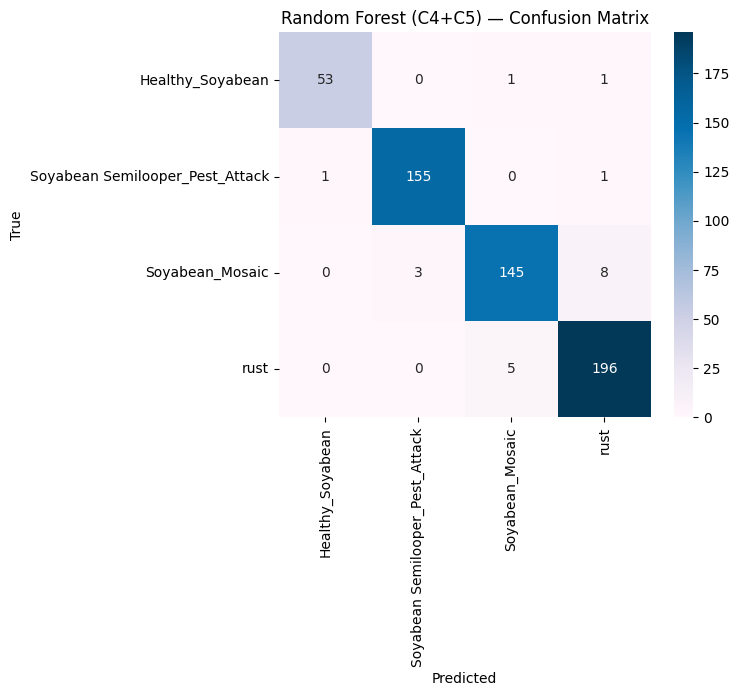

In [10]:
rf_cm_c4c5 = confusion_matrix(test_labels, rf_pred_labels_c4c5)
plt.figure(figsize=(6,5))
sns.heatmap(rf_cm_c4c5, annot=True, fmt='d', cmap='PuBu',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Random Forest (C4+C5) — Confusion Matrix")
plt.show()

# classification report - c4+c5

In [11]:
print("Random Forest (C4+C5) — Classification Report\n",
      classification_report(test_labels, rf_pred_labels_c4c5,
                             target_names=label_encoder.classes_, digits=4))

print(f"C4+C5 Accuracy: {accuracy_score(test_labels, rf_pred_labels_c4c5):.4f}")

Random Forest (C4+C5) — Classification Report
                                  precision    recall  f1-score   support

               Healthy_Soyabean     0.9815    0.9636    0.9725        55
Soyabean Semilooper_Pest_Attack     0.9810    0.9873    0.9841       157
                Soyabean_Mosaic     0.9603    0.9295    0.9446       156
                           rust     0.9515    0.9751    0.9631       201

                       accuracy                         0.9649       569
                      macro avg     0.9686    0.9639    0.9661       569
                   weighted avg     0.9649    0.9649    0.9648       569

C4+C5 Accuracy: 0.9649


# Multiclass ROC - c4+c5

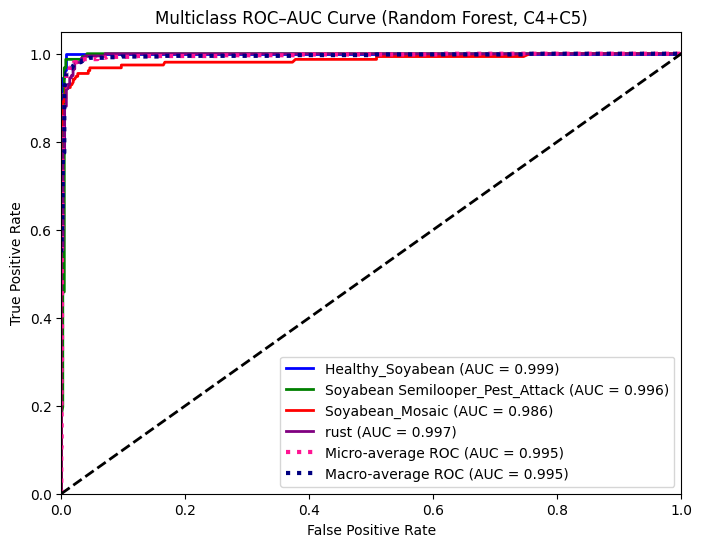

In [12]:
num_classes = len(label_encoder.classes_)
y_test_bin = label_binarize(test_labels, classes=range(num_classes))
y_pred_proba = rf_pred_probs_c4c5

fpr = dict(); tpr = dict(); roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= num_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(8,6))
colors = ["blue", "green", "red", "purple"]
for i, class_name in enumerate(label_encoder.classes_):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f"{class_name} (AUC = {roc_auc[i]:.3f})")
plt.plot(fpr["micro"], tpr["micro"], color="deeppink", linestyle=":", linewidth=3,
         label=f"Micro-average ROC (AUC = {roc_auc['micro']:.3f})")
plt.plot(fpr["macro"], tpr["macro"], color="navy", linestyle=":", linewidth=3,
         label=f"Macro-average ROC (AUC = {roc_auc['macro']:.3f})")
plt.plot([0,1], [0,1], "k--", lw=2)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC–AUC Curve (Random Forest, C4+C5)")
plt.legend(loc="lower right")
plt.show()